In [15]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import f1_score, make_scorer, classification_report, confusion_matrix

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


Dataset salvo como ..\datasets\vict\10v\data.csv

Número de vítimas por classificação START:
  0 (verde): 1467
  1 (amarelo): 1477
  2 (vermelho): 1503
  3 (preto): 553


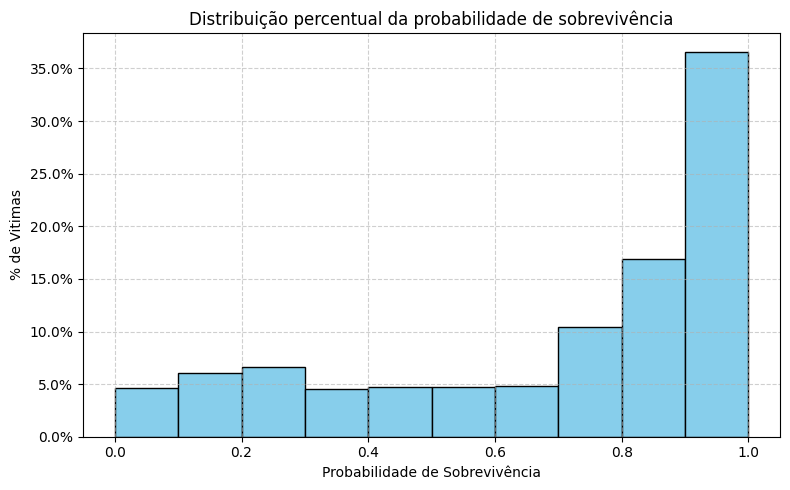

In [16]:
from collections import Counter
import sys
import os

sys.path.append(os.path.abspath("data_creation"))
from gerar_dados_vitimas import gerar_dataset_vitimas


# Parâmetros do dataset (fixos para o trabalho)
N_VITIMAS = 5000
MEDIA_IDADE = 45
DESVIO_IDADE = 5
TIPO_ACIDENTE = "ferroviario"
NIVEL_RUIDO = 0.03
SEED_TREINO = 50
SEED_TESTE = 89

# Dataset de treino/validação
df_treino_val = gerar_dataset_vitimas(
    n_vitimas=N_VITIMAS,
    media_idade=MEDIA_IDADE,
    desvio_idade=DESVIO_IDADE,
    tipo_acidente=TIPO_ACIDENTE,
    nivel_ruido=NIVEL_RUIDO,
    seed=SEED_TREINO
)

In [17]:
print("Formato do dataset:", df_treino_val.shape)

print(df_treino_val.dtypes)

display(df_treino_val.head())

display(df_treino_val.describe())

Formato do dataset: (5000, 14)
idade      int64
fc         int64
fr         int64
pas        int64
spo2       int64
temp     float64
pr         int64
sg         int64
fx         int64
queim      int64
gcs        int64
avpu       int64
tri        int64
sobr     float64
dtype: object


,idade,fc,fr,pas,spo2,temp,pr,sg,fx,queim,gcs,avpu,tri,sobr
0,46,104,28,105,90,38.150369,0,2,1,0,13,0,1,0.78
1,46,66,15,130,94,36.857071,1,0,1,0,15,0,0,1.00
2,45,71,15,111,98,37.694191,1,0,1,0,15,0,0,0.95
3,51,109,24,99,89,37.571212,0,1,0,1,13,1,1,0.88
4,40,112,25,95,89,37.109097,0,1,0,0,13,1,1,0.79


,idade,fc,fr,pas,spo2,temp,pr,sg,fx,queim,gcs,avpu,tri,sobr
count,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,44.589400,98.448400,23.24920,87.703800,84.594400,35.716962,0.442400,1.658000,0.794600,0.673200,11.762400,1.059400,1.228400,0.690446
std,5.147204,41.710614,11.95783,34.975968,19.081958,2.588053,0.496721,1.274896,0.404034,1.142043,3.310852,1.076152,0.992185,0.297582
min,24.000000,0.000000,0.00000,0.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000
25%,41.000000,79.000000,16.00000,74.000000,81.000000,34.491814,0.000000,0.000000,1.000000,0.000000,10.000000,0.000000,0.000000,0.460000
50%,45.000000,106.000000,23.00000,96.000000,91.000000,36.753012,0.000000,2.000000,1.000000,0.000000,13.000000,1.000000,1.000000,0.810000
75%,48.000000,127.000000,33.00000,113.000000,96.000000,37.441711,1.000000,3.000000,1.000000,1.000000,15.000000,2.000000,2.000000,0.930000
max,63.000000,165.000000,45.00000,135.000000,100.000000,38.962280,1.000000,3.000000,1.000000,3.000000,15.000000,3.000000,3.000000,1.000000


In [18]:
print("Distribuição da variável alvo (tri):")
print(df_treino_val["tri"].value_counts().sort_index())

print("\nDistribuição percentual:")
print(df_treino_val["tri"].value_counts(normalize=True).sort_index() * 100)

Distribuição da variável alvo (tri):
tri
0    1467
1    1477
2    1503
3     553
Name: count, dtype: int64

Distribuição percentual:
tri
0    29.34
1    29.54
2    30.06
3    11.06
Name: proportion, dtype: float64


In [19]:
# variável alvo (target)
y = df_treino_val["tri"]

# colunas proibidas pelo trabalho
colunas_proibidas = ["gcs", "avpu", "tri", "sobr"]

# features (entradas)
X = df_treino_val.drop(columns=colunas_proibidas)

print("Features utilizadas:")
print(list(X.columns))

print("\nFormato de X:", X.shape)
print("Formato de y:", y.shape)

Features utilizadas:
['idade', 'fc', 'fr', 'pas', 'spo2', 'temp', 'pr', 'sg', 'fx', 'queim']

Formato de X: (5000, 10)
Formato de y: (5000,)


In [23]:
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
import numpy as np

In [25]:
# Parâmetros

k_folds = 5
num_params = 3          # num de parametrizacoes a treinar
max_depth=[2, 4, 16]
min_samples_leaf=[1, 5, 10] 
criterion = ["gini", "gini", "entropy"]

# Validação cruzada
skf = StratifiedKFold( n_splits=k_folds, shuffle=True, random_state=42)

# Vars para salvar resultados
train_scores=[]
vld_scores=[]
modelos_cart = []

In [ ]:
for i in range(num_params):

    f1_treino_folds = []
    f1_vali_folds = []

    for treino_index, vali_index in skf.split(X,y):

        X_treino_fold = X.iloc[treino_index]
        X_vali_fold = X.iloc[vali_index]
        y_treino_fold = y.iloc[treino_index]
        y_val_fold = y.iloc[vali_index]

        # Criar modelo com a parametrização i
        
        dt = DecisionTreeClassifier(
            max_depth=max_depth[i],
            min_samples_leaf=min_samples_leaf[i],
            criterion=criterion[i],
            random_state=42
        )

        # Treinar
        dt.fit(X_treino_fold, y_treino_fold)

        # Previsões
        y_pred_treino = dt.predict(X_treino_fold)
        y_pred_vali = dt.predict(X_vali_fold)

        # Calcular f1-score
        f1_treino = f1_score(y_treino_fold, y_pred_treino, average="macro")
        f1_vali = f1_score(y_val_fold, y_pred_vali, average="macro")

        f1_treino_folds.append(f1_treino)
        f1_vali_folds.append(f1_vali)

    #salvar Resultador da parametrização
    train_scores.append(f1_treino_folds)
    vld_scores.append(f1_vali_folds)
    modelos_cart.append(dt)





In [28]:
print("F1 treino por parametrização:")
print(train_scores)

print("\nF1 validação por parametrização:")
print(vld_scores)

F1 treino por parametrização:
[[0.6952013755028223, 0.6946168997184448, 0.6938114087008882, 0.693052413706812, 0.6954892541093446], [0.9627609934174549, 0.9638130796145393, 0.9650413200619166, 0.9628268171973737, 0.9667350003405125], [0.9627609934174549, 0.9638130796145393, 0.9650413200619166, 0.9628268171973737, 0.9667350003405125]]

F1 validação por parametrização:
[[0.691354398944807, 0.6937131560153152, 0.6969240325321577, 0.6999640698789941, 0.6902464346903199], [0.9698492936350853, 0.9659412884030221, 0.9610034705367193, 0.9699050780723375, 0.954136105391136], [0.9698492936350853, 0.9659412884030221, 0.9610034705367193, 0.9699050780723375, 0.954136105391136]]


In [30]:
resultados = []

for i in range(num_params):

    f1_treino = train_scores[i]
    f1_vali = vld_scores[i]

    media_treino = np.mean(f1_treino)
    media_vali = np.mean(f1_vali)

    var_treino = np.var(f1_treino)
    var_vali = np.var(f1_vali)

    diff_f1 = abs(media_treino - media_vali)
    diff_var = abs(var_treino - var_vali)

    resultados.append({
        "max_depth": max_depth[i],
        "min_samples_leaf": min_samples_leaf[i],
        "criterion": criterion[i],
        "f1_treino_medio": media_treino,
        "f1_val_medio": media_vali,
        "diff_f1": diff_f1,
        "var_vali": var_vali,
        "diff_var": diff_var
    })

df_resultados_cart = pd.DataFrame(resultados)

display(df_resultados_cart)

,max_depth,min_samples_leaf,criterion,f1_treino_medio,f1_val_medio,diff_f1,var_vali,diff_var
0,2,1,gini,0.694434,0.694440,0.000006,0.000013,0.000012
1,4,5,gini,0.964235,0.964167,0.000068,0.000036,0.000034
2,16,10,entropy,0.964235,0.964167,0.000068,0.000036,0.000034


In [33]:
#Selecionando os melhores parâmetros
df_resultados_cart = df_resultados_cart.sort_values(by="f1_val_medio", ascending=False)

melhores_params = df_resultados_cart.iloc[0]

# Criando o melhor modelo
melhor_cart_modelo = DecisionTreeClassifier(
    max_depth=melhores_params["max_depth"],
    min_samples_leaf=melhores_params["min_samples_leaf"],
    criterion=melhores_params["criterion"],
    random_state=42
)

# Treinando com TODOS os dados
melhor_cart_modelo.fit(X,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",np.int64(4)
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",np.int64(5)
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl